In [1]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

import warnings
warnings.filterwarnings("ignore")

# Reading and understanding the data

In [2]:
#Load the dataset
df = pd.read_csv("topic21_v49_train.csv")

In [3]:
df.head()

,0,1,2,3,4,brand,model,trim,body_type,fuel_type,transmission_type,engine_capacity_cc,horsepower,exterior_color,interior_color,warranty,city,seller_type,price
0,NaN,9.724281,-42.273130,NaN,1.063697,Mercedes-Benz,E-Class,E 350,Sedan,Petrol,Automatic Transmission,3500 - 3999 cc,200 - 299 HP,White,Beige,No,Dubai,Dealer,199000
1,4.628419,9.762487,23.062189,0.551743,1.179203,Jeep,Wrangler Unlimited,Sahara,SUV,Petrol,Automatic Transmission,3000 - 3499 cc,200 - 299 HP,White,Unknown,Yes,Dubai,Dealer,149000
2,5.350131,9.724223,4.214038,0.531376,NaN,Lexus,RX-Series,Other,Hatchback,Petrol,Automatic Transmission,NaN,Unknown,Red,Beige,No,Dubai,Owner,46000
3,4.760718,9.750312,158.766323,0.261981,0.183436,Rolls-Royce,Cullinan,Other,SUV,Petrol,Automatic Transmission,NaN,500 - 599 HP,Black,Black,Yes,Dubai,Dealer,1790
4,5.107892,9.722766,NaN,0.562016,0.889407,Mercedes-Benz,C-Class,C300 Luxury,Sports Car,Petrol,Automatic Transmission,1500 - 1999 cc,200 - 299 HP,White,Beige,No,Abu Dhabi,Owner,76000


In [4]:
df.shape

(7962, 19)

In [5]:
#Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7962 entries, 0 to 7961
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   0                   7421 non-null   float64
 1   1                   7359 non-null   float64
 2   2                   7269 non-null   float64
 3   3                   7249 non-null   float64
 4   4                   7288 non-null   float64
 5   brand               7962 non-null   object 
 6   model               7962 non-null   object 
 7   trim                7951 non-null   object 
 8   body_type           7962 non-null   object 
 9   fuel_type           7962 non-null   object 
 10  transmission_type   7962 non-null   object 
 11  engine_capacity_cc  6362 non-null   object 
 12  horsepower          7584 non-null   object 
 13  exterior_color      7962 non-null   object 
 14  interior_color      7962 non-null   object 
 15  warranty            7962 non-null   object 
 16  city  

In [6]:
#Check missing values 
df.isnull().sum()

0                      541
1                      603
2                      693
3                      713
4                      674
brand                    0
model                    0
trim                    11
body_type                0
fuel_type                0
transmission_type        0
engine_capacity_cc    1600
horsepower             378
exterior_color           0
interior_color           0
warranty                 0
city                     0
seller_type              0
price                    0
dtype: int64

There are some few columns that has missing values. We will impute the missing values with simple imputer.

In [7]:
# Basic statictics of the dataset
df.describe()

,0,1,2,3,4,price
count,7421.000000,7359.000000,7269.000000,7249.000000,7288.000000,7962.000000
mean,4.880715,9.722233,-2.123038,35.609868,1.077579,163331.653228
std,0.457550,0.028205,66.004729,2015.819311,0.551472,188397.899880
min,4.165617,9.652803,-218.061391,0.217301,0.163702,1000.000000
25%,4.581000,9.713573,-48.114873,0.353311,0.819573,44999.250000
50%,4.816920,9.726132,-12.016120,0.447565,1.001239,93000.000000
75%,5.095007,9.741392,38.401469,0.598267,1.269995,207000.000000
max,10.060015,9.765084,215.036743,121773.949438,3.628345,999900.000000


In [8]:
#Convert "range strings" into numeric averages
def convert_range_to_avg(value):
    try:
        parts = str(value).replace(" HP", "").replace(" cc", "").split(" - ")
        return np.mean([float(num) for num in parts])
    except Exception:
        return np.nan

df["horsepower"] = df["horsepower"].apply(convert_range_to_avg)
df["engine_capacity_cc"] = df["engine_capacity_cc"].apply(convert_range_to_avg)

The horsepower and engine capacity cc columns contains range values with string variable. We convert the ranges values into single numeric values

In [9]:
#Splits data into train and test(train 80% and test 20% of data)
y = df["price"]
X = df.drop(columns="price")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Exploratory Data Analysis (EDA)

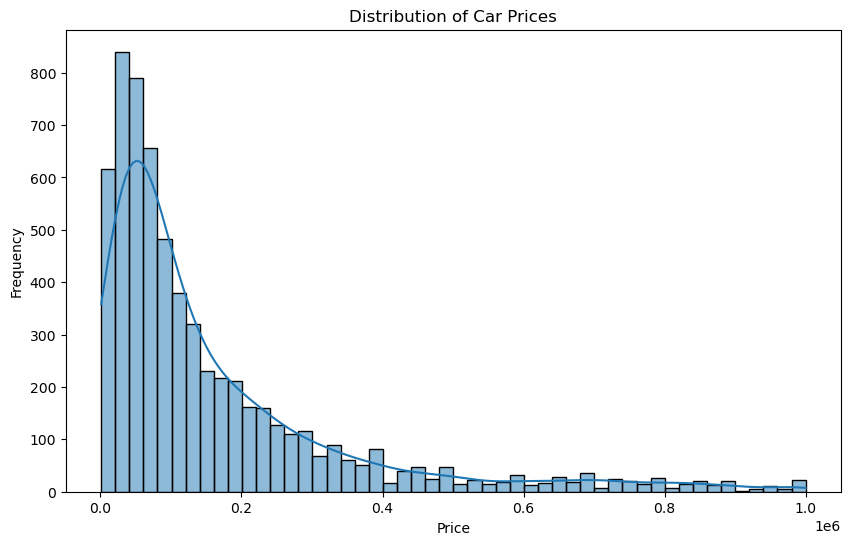

In [10]:
#Distribution of car prices
train_df = X_train.copy()
train_df["price"] = y_train.values

plt.figure(figsize=(10,6))
sns.histplot(y_train, bins=50, kde=True,)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


Most cars in the dataset are priced below 200,000, with the largest group between 20,000 and 100,000. A few luxury cars have very high prices, reaching up to 1,000,000. The distribution is right-skewed, meaning cheaper cars are much more common than expensive ones.

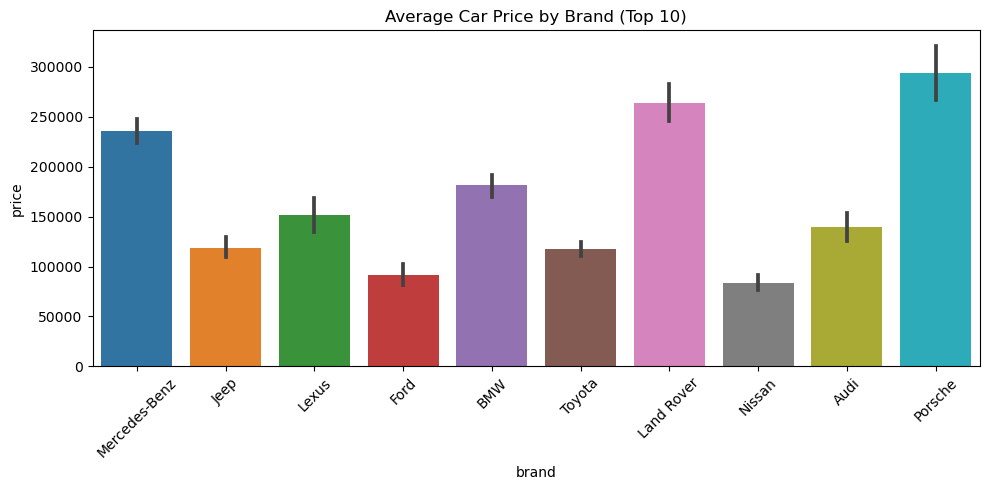

In [11]:
top_brands = df['brand'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 5))
sns.barplot(data=df[df['brand'].isin(top_brands)], x='brand', y='price')
plt.title("Average Car Price by Brand (Top 10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Luxury brands like Porsche, Land Rover, and Mercedes-Benz have the highest average car prices. BMW, Lexus, and Audi are in the mid-range, while Ford, Nissan, Toyota, and Jeep are among the more affordable brands. This shows a clear price gap between luxury and regular car brands.

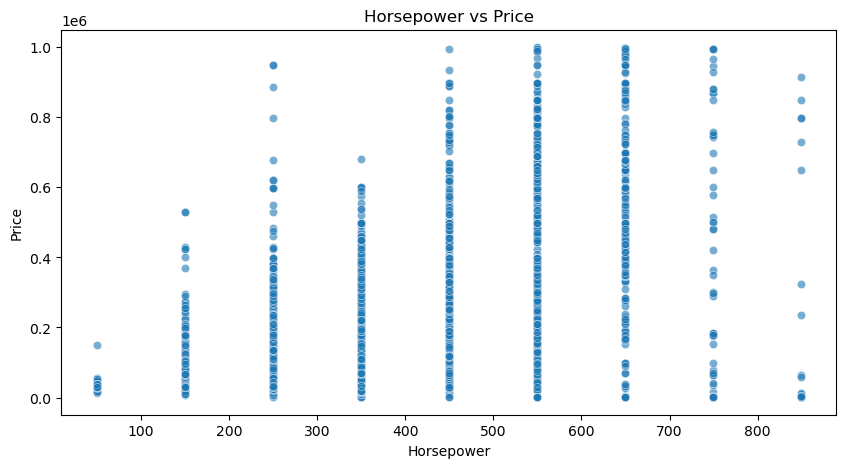

In [12]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=X_train["horsepower"], y=y_train, alpha=0.6)
plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

Cars with higher horsepower usually have higher prices, showing a clear positive trend

# Preprocessing Pipelines

In [13]:
# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

we split the features into numeric columns and categorical columns. This allows us to handle each group differently during preprocessing.

In [14]:
# Preprocessing Pipelines
# Numeric features: impute missing values with median, then scale
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical features: impute with mode, then one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps for numeric + categorical columns
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


In this step, we created preprocessing pipelines:
  1)For numeric features, we filled missing values with the median and scaled them.
  2)For categorical features, we filled missing values with the most frequent value and applied one-hot encoding.
  3)Then we combined both into a single ColumnTransformer to handle all columns in one step.

# Model 1 - Ridge Regression

In [15]:
# MODEL 1: Ridge Regression
ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    ("ridge", Ridge())
])

In this step, we created our first model pipeline using Ridge Regression. We combined the preprocessing steps with the Ridge model.

In [16]:
# Hyperparameter tunning with GridSearchCV
param_grid = {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_search = GridSearchCV(
    ridge_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0
)

ridge_search.fit(X_train, y_train)
ridge_best = ridge_search.best_estimator_


we tuned the Ridge Regression model using GridSearchCV. We tested different values of the regularization parameter alpha with 5-fold cross-validation and selected the model that gave the best performance.

In [17]:
# Evaluation
ridge_train_pred = ridge_best.predict(X_train)
ridge_test_pred  = ridge_best.predict(X_test)

print("Ridge Regression Performance:")
print(f"Train R²:  {r2_score(y_train, ridge_train_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, ridge_test_pred):.2f}")
print(f"Train MSE: {mean_squared_error(y_train, ridge_train_pred):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, ridge_test_pred):.2f}")

Ridge Regression Performance:
Train R²:  0.65
Test R²:   0.49
Train MSE: 12506607816.46
Test MSE:  18403202546.76


from our evaluation, The Ridge Regression training score was 65% while the test score dropped to 49%. This drop shows the model fits the training data better than the test data, which hints at some overfitting. Still, the test score means the model can explain almost half of the variation in car prices. That’s a reasonable result, but it also shows Ridge is not capturing the full complexity of the problem.

# Model 2 - KNN Regression

In [18]:
# MODEL 2: KNN Regression
knn_model = Pipeline([
    ("preprocessing", preprocessor),
    ("knn", KNeighborsRegressor())
])

In [19]:
# Hyperparameter tunning with RandomSearchCV
param_dist_knn = {"knn__n_neighbors": np.arange(1, 31)}

knn_search = RandomizedSearchCV(
    knn_model,
    param_distributions=param_dist_knn,
    n_iter=10,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

knn_search.fit(X_train, y_train)
knn_best = knn_search.best_estimator_

we tuned the KNN model using RandomizedSearchCV. We tested different numbers of neighbors with cross-validation.

In [20]:
# Predictions
knn_train_pred = knn_best.predict(X_train)
knn_test_pred  = knn_best.predict(X_test)

print("KNN Regression Performance:")
print(f"Train R²:  {r2_score(y_train, knn_train_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, knn_test_pred):.2f}")
print(f"Train MSE: {mean_squared_error(y_train, knn_train_pred):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, knn_test_pred):.2f}")

KNN Regression Performance:
Train R²:  0.62
Test R²:   0.50
Train MSE: 13305141497.48
Test MSE:  17888513859.03


The KNN regression model explains 50% variation in the car prices on unseen data while the model achieved 62% of training score. we see that, The model fits the training data slightly better than new data. This is not severe overfitting, as the model performs fairly consistently across both sets. Overall, the KNN model captures basic relationships in the data but struggles to make accurate predictions for new, unseen cars.

# Model 3 - Random Forest Regression

In [21]:
#MODEL 3: Random Forest
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("rf", RandomForestRegressor(random_state=42))
])

In [22]:
# Hyperparameter space for Random Forest
param_dist_rf = {
    "rf__n_estimators": randint(150, 300),
    "rf__max_depth": [15, 20, 25, None],
    "rf__min_samples_split": randint(2, 10),
    "rf__min_samples_leaf": randint(1, 5),
    "rf__max_features": ["sqrt", "log2"]
}

We defined the settings to test for the Random Forest model, like the number of trees, tree depth, and split rules. These will be used to find the best model with RandomizedSearchCV.

In [23]:
# Hyperparameter tunning
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_


we tuned the Random Forest model using RandomizedSearchCV. We tested 30 random hyperparameter combinations with cross-validation and picked the best model based on the R2 score.

In [24]:
# Predictions
rf_train_pred = rf_best.predict(X_train)
rf_test_pred  = rf_best.predict(X_test)

print("Random Forest Performance:")
print(f"Train R²:  {r2_score(y_train, rf_train_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, rf_test_pred):.2f}")
print(f"Train MSE: {mean_squared_error(y_train, rf_train_pred):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, rf_test_pred):.2f}")



Random Forest Performance:
Train R²:  0.81
Test R²:   0.55
Train MSE: 6740431984.22
Test MSE:  16188176171.85


we can see that, the dropped from the training to test score is slighty bigger compared to other models. the model generalized well on unseen data but it causes some overfitting, but not too much. The model explains 81% on training data while 55% for test data.

# MODEL COMPARISON

In [25]:
# Create a dictionary of model performances
results = {
    "Model": ["Ridge Regression", "KNN Regression", "Random Forest"],
    "Train R²": [
        r2_score(y_train, ridge_train_pred),
        r2_score(y_train, knn_train_pred),
        r2_score(y_train, rf_train_pred)
    ],
    "Test R²": [
        r2_score(y_test, ridge_test_pred),
        r2_score(y_test, knn_test_pred),
        r2_score(y_test, rf_test_pred)
    ],
    "Train MSE": [
        mean_squared_error(y_train, ridge_train_pred),
        mean_squared_error(y_train, knn_train_pred),
        mean_squared_error(y_train, rf_train_pred)
    ],
    "Test MSE": [
        mean_squared_error(y_test, ridge_test_pred),
        mean_squared_error(y_test, knn_test_pred),
        mean_squared_error(y_test, rf_test_pred)
    ]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(results).round(3)

# Display table
print("Model Performance Comparison:")
print(comparison_df)


Model Performance Comparison:
              Model  Train R²  Test R²     Train MSE      Test MSE
0  Ridge Regression     0.646    0.489  1.250661e+10  1.840320e+10
1    KNN Regression     0.624    0.504  1.330514e+10  1.788851e+10
2     Random Forest     0.809    0.551  6.740432e+09  1.618818e+10


# Error Analysis

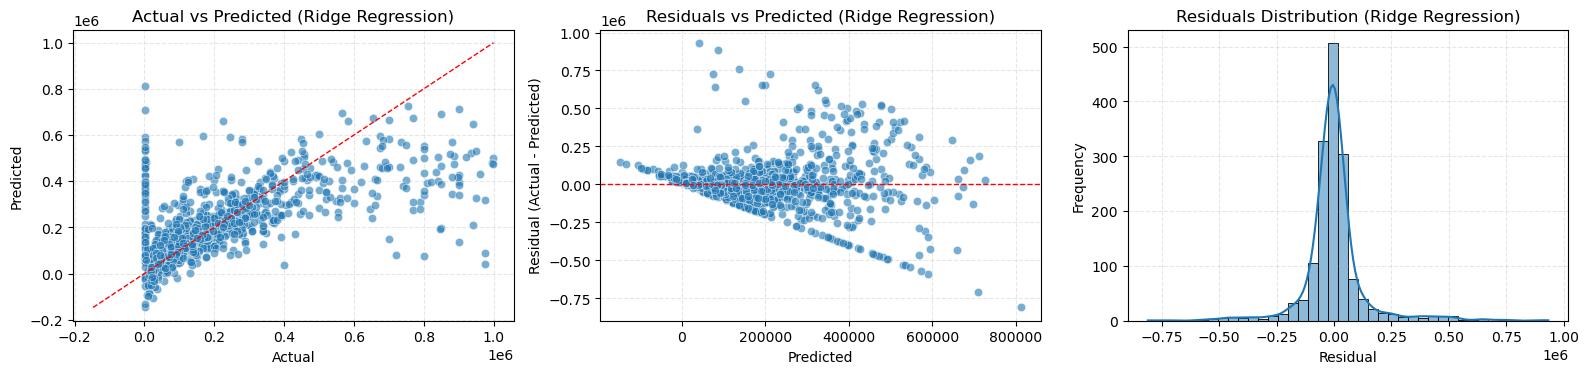

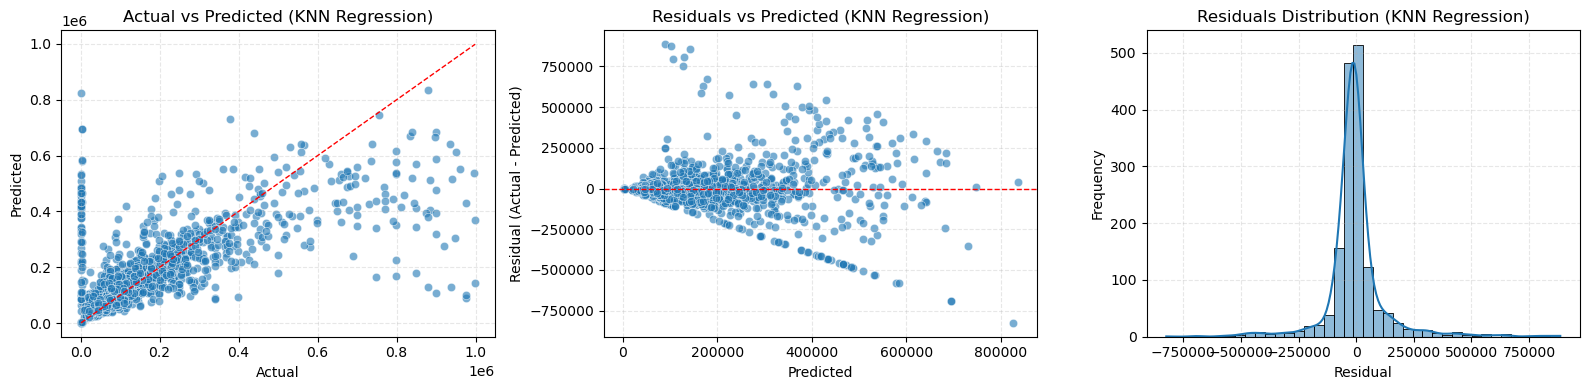

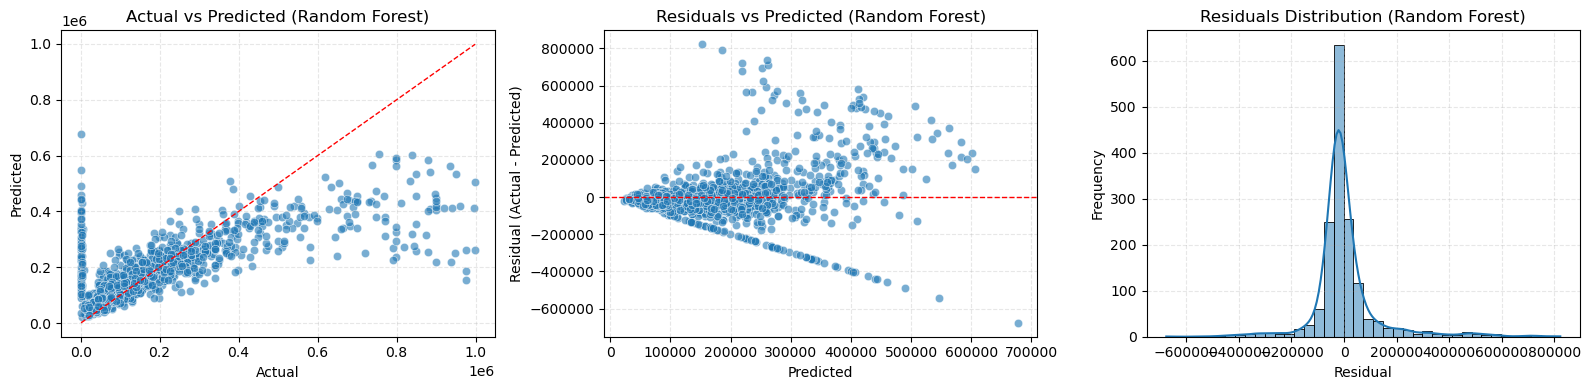

In [26]:
def error_panel(y_true, y_pred, model_name):
    
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # (1) Actual vs Predicted
    ax = axes[0]
    sns.scatterplot(ax=ax, x=y_true, y=y_pred, alpha=0.6)
    lo = float(min(np.min(y_true), np.min(y_pred)))
    hi = float(max(np.max(y_true), np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)  # 45° reference
    ax.set_title(f"Actual vs Predicted ({model_name})")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # (2) Residuals vs Predicted
    ax = axes[1]
    sns.scatterplot(ax=ax, x=y_pred, y=residuals, alpha=0.6)
    ax.axhline(0, color="r", linestyle="--", linewidth=1)
    ax.set_title(f"Residuals vs Predicted ({model_name})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # (3) Residuals histogram
    ax = axes[2]
    sns.histplot(ax=ax, x=residuals, bins=40, kde=True)
    ax.set_title(f"Residuals Distribution ({model_name})")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    fig.tight_layout()
    plt.show()

# Call once per model
error_panel(y_test, ridge_test_pred, "Ridge Regression")
error_panel(y_test, knn_test_pred,  "KNN Regression")
error_panel(y_test, rf_test_pred,   "Random Forest")
